# Домашнее задание HW06: Деревья решений и ансамбли

Тема: деревья решений и ансамбли (bagging / random forest / boosting / stacking) и честный ML-эксперимент.

Выбран датасет: S06-hw-dataset-01.csv (бинарная классификация, умеренный дисбаланс).

In [1]:
# Импорт библиотек
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import os

In [2]:
# Загрузка данных
data_path = 'S06-hw-dataset-01.csv'
df = pd.read_csv(data_path)
print("Первые 5 строк:")
print(df.head())
print("\nИнформация о данных:")
print(df.info())
print("\nСтатистики:")
print(df.describe())
print("\nРаспределение таргета:")
print(df['target'].value_counts(normalize=True))

Первые 5 строк:
   id     num01     num02     num03     num04     num05     num06     num07  \
0   1 -0.946058 -0.070313  1.824445 -2.754422  0.808865 -0.111094 -0.268950   
1   2 -2.484027  0.739378  1.596908 -2.586479 -0.033225 -3.054412 -4.706908   
2   3  1.522629  7.159635 -0.564903 -4.493110  1.623610  5.450187 -0.974595   
3   4  0.463373 -1.073908  1.752813  0.362786  2.790872  4.082385  0.322283   
4   5  3.188390 -4.701692 -0.689918 -0.448995  0.373821 -3.275363 -1.760931   

      num08     num09  ...     num20     num21     num22     num23     num24  \
0 -3.078210  0.801275  ... -1.616515 -1.989464  1.407390 -0.218362  2.016052   
1 -9.795169  0.145911  ... -1.727040 -0.583997  1.136761  0.285978 -0.310879   
2 -5.189589  1.600591  ...  0.524408  2.022430  1.278358 -0.850547  0.847457   
3  3.390984 -0.033929  ...  2.399834 -1.431576 -0.746987  0.049639  2.414689   
4  0.923689  0.537345  ... -2.183407 -2.896590  2.440343 -1.097168  1.457323   

   cat_contract  cat_region 

In [3]:
# Определение X и y
X = df.drop(columns=['id', 'target'])
y = df['target']
print(f"Размер X: {X.shape}, размер y: {y.shape}")

Размер X: (12000, 28), размер y: (12000,)


In [4]:
# Train/Test-сплит
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")
print("Фиксированный random_state=42 обеспечивает воспроизводимость. Stratify=y сохраняет пропорции классов.")

Train size: 9600, Test size: 2400
Фиксированный random_state=42 обеспечивает воспроизводимость. Stratify=y сохраняет пропорции классов.


In [5]:
# Baselines
# DummyClassifier
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)
y_prob_dummy = dummy.predict_proba(X_test)[:, 1] if hasattr(dummy, 'predict_proba') else None

acc_dummy = accuracy_score(y_test, y_pred_dummy)
f1_dummy = f1_score(y_test, y_pred_dummy)
roc_auc_dummy = roc_auc_score(y_test, y_prob_dummy) if y_prob_dummy is not None else 'N/A'

print("DummyClassifier:")
print(f"Accuracy: {acc_dummy:.4f}, F1: {f1_dummy:.4f}, ROC-AUC: {roc_auc_dummy}")

# LogisticRegression
pipe_lr = Pipeline([('scaler', StandardScaler()), ('lr', LogisticRegression(random_state=42))])
pipe_lr.fit(X_train, y_train)
y_pred_lr = pipe_lr.predict(X_test)
y_prob_lr = pipe_lr.predict_proba(X_test)[:, 1]

acc_lr = accuracy_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
roc_auc_lr = roc_auc_score(y_test, y_prob_lr)

print("LogisticRegression:")
print(f"Accuracy: {acc_lr:.4f}, F1: {f1_lr:.4f}, ROC-AUC: {roc_auc_lr:.4f}")

DummyClassifier:
Accuracy: 0.6767, F1: 0.0000, ROC-AUC: 0.5
LogisticRegression:
Accuracy: 0.8275, F1: 0.7076, ROC-AUC: 0.8747


In [6]:
# DecisionTreeClassifier
param_grid_dt = {
    'max_depth': [3, 5, 10, None],
    'min_samples_leaf': [1, 5, 10]
}
grid_dt = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid_dt, cv=5, scoring='roc_auc')
grid_dt.fit(X_train, y_train)
best_dt = grid_dt.best_estimator_
print(f"Best params DT: {grid_dt.best_params_}")

y_pred_dt = best_dt.predict(X_test)
y_prob_dt = best_dt.predict_proba(X_test)[:, 1]

acc_dt = accuracy_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
roc_auc_dt = roc_auc_score(y_test, y_prob_dt)

print("DecisionTree:")
print(f"Accuracy: {acc_dt:.4f}, F1: {f1_dt:.4f}, ROC-AUC: {roc_auc_dt:.4f}")

Best params DT: {'max_depth': 10, 'min_samples_leaf': 10}
DecisionTree:
Accuracy: 0.8767, F1: 0.8000, ROC-AUC: 0.9069


In [7]:
# RandomForestClassifier
param_grid_rf = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None],
    'min_samples_leaf': [1, 5]
}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=5, scoring='roc_auc')
grid_rf.fit(X_train, y_train)
best_rf = grid_rf.best_estimator_
print(f"Best params RF: {grid_rf.best_params_}")

y_pred_rf = best_rf.predict(X_test)
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]

acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("RandomForest:")
print(f"Accuracy: {acc_rf:.4f}, F1: {f1_rf:.4f}, ROC-AUC: {roc_auc_rf:.4f}")

Best params RF: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 100}
RandomForest:
Accuracy: 0.9275, F1: 0.8823, ROC-AUC: 0.9666


In [8]:
# GradientBoostingClassifier
param_grid_gb = {
    'n_estimators': [50, 100],
    'learning_rate': [0.1, 0.2],
    'max_depth': [3, 5]
}
grid_gb = GridSearchCV(GradientBoostingClassifier(random_state=42), param_grid_gb, cv=5, scoring='roc_auc')
grid_gb.fit(X_train, y_train)
best_gb = grid_gb.best_estimator_
print(f"Best params GB: {grid_gb.best_params_}")

y_pred_gb = best_gb.predict(X_test)
y_prob_gb = best_gb.predict_proba(X_test)[:, 1]

acc_gb = accuracy_score(y_test, y_pred_gb)
f1_gb = f1_score(y_test, y_pred_gb)
roc_auc_gb = roc_auc_score(y_test, y_prob_gb)

print("GradientBoosting:")
print(f"Accuracy: {acc_gb:.4f}, F1: {f1_gb:.4f}, ROC-AUC: {roc_auc_gb:.4f}")

Best params GB: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 100}
GradientBoosting:
Accuracy: 0.9308, F1: 0.8896, ROC-AUC: 0.9684


In [9]:
# StackingClassifier
estimators = [
    ('dt', DecisionTreeClassifier(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42)),
    ('gb', GradientBoostingClassifier(random_state=42))
]
stacking = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression(random_state=42), cv=5)
stacking.fit(X_train, y_train)

y_pred_st = stacking.predict(X_test)
y_prob_st = stacking.predict_proba(X_test)[:, 1]

acc_st = accuracy_score(y_test, y_pred_st)
f1_st = f1_score(y_test, y_pred_st)
roc_auc_st = roc_auc_score(y_test, y_prob_st)

print("Stacking:")
print(f"Accuracy: {acc_st:.4f}, F1: {f1_st:.4f}, ROC-AUC: {roc_auc_st:.4f}")

Stacking:
Accuracy: 0.9296, F1: 0.8886, ROC-AUC: 0.9662


In [10]:
# Сравнение метрик
models = ['Dummy', 'LogisticRegression', 'DecisionTree', 'RandomForest', 'GradientBoosting', 'Stacking']
accuracies = [acc_dummy, acc_lr, acc_dt, acc_rf, acc_gb, acc_st]
f1s = [f1_dummy, f1_lr, f1_dt, f1_rf, f1_gb, f1_st]
roc_aucs = [roc_auc_dummy if isinstance(roc_auc_dummy, float) else 0, roc_auc_lr, roc_auc_dt, roc_auc_rf, roc_auc_gb, roc_auc_st]

results = pd.DataFrame({
    'Model': models,
    'Accuracy': accuracies,
    'F1': f1s,
    'ROC-AUC': roc_aucs
})
print(results)

# Лучшая модель по ROC-AUC
best_idx = np.argmax(roc_aucs)
best_model_name = models[best_idx]
best_model = [dummy, pipe_lr, best_dt, best_rf, best_gb, stacking][best_idx]
print(f"Лучшая модель: {best_model_name} с ROC-AUC: {roc_aucs[best_idx]:.4f}")

                Model  Accuracy        F1   ROC-AUC
0               Dummy  0.676667  0.000000  0.500000
1  LogisticRegression  0.827500  0.707627  0.874691
2        DecisionTree  0.876667  0.800000  0.906921
3        RandomForest  0.927500  0.882273  0.966560
4    GradientBoosting  0.930833  0.889628  0.968449
5            Stacking  0.929583  0.888596  0.966211
Лучшая модель: GradientBoosting с ROC-AUC: 0.9684


In [14]:
# Проверка устойчивости для GradientBoosting
random_states = [42, 123, 456, 789, 101]
roc_aucs_stability = []

for rs in random_states:
    X_train_stab, X_test_stab, y_train_stab, y_test_stab = train_test_split(X, y, test_size=0.2, random_state=rs, stratify=y)
    gb_stab = GradientBoostingClassifier(n_estimators=100, learning_rate=0.2, max_depth=5, random_state=rs)
    gb_stab.fit(X_train_stab, y_train_stab)
    y_prob_stab = gb_stab.predict_proba(X_test_stab)[:, 1]
    roc_auc_stab = roc_auc_score(y_test_stab, y_prob_stab)
    roc_aucs_stability.append(roc_auc_stab)

print(f"ROC-AUC для разных random_state: {roc_aucs_stability}")
print(f"Среднее: {np.mean(roc_aucs_stability):.4f}, Std: {np.std(roc_aucs_stability):.4f}")

ROC-AUC для разных random_state: [0.9684492598141282, 0.9713146234320249, 0.9713487443502108, 0.965836232288863, 0.9756241747498857]
Среднее: 0.9705, Std: 0.0033


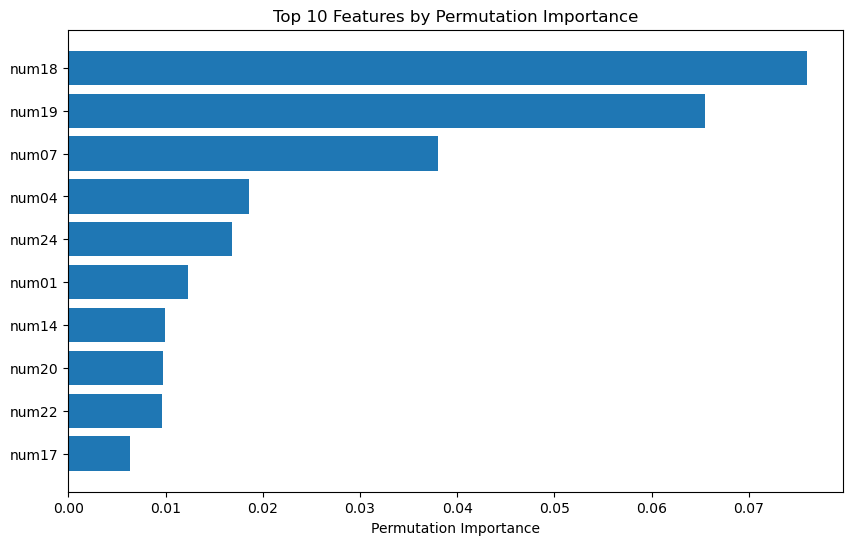

Top 10 признаков по permutation importance:
num18: 0.0759
num19: 0.0655
num07: 0.0380
num04: 0.0186
num24: 0.0169
num01: 0.0123
num14: 0.0099
num20: 0.0097
num22: 0.0096
num17: 0.0063


In [11]:
# Интерпретация лучшей модели
perm_importance = permutation_importance(best_model, X_test, y_test, n_repeats=10, random_state=42, scoring='roc_auc')
sorted_idx = perm_importance.importances_mean.argsort()[::-1]
top_features = X.columns[sorted_idx][:10]
top_importances = perm_importance.importances_mean[sorted_idx][:10]

plt.figure(figsize=(10, 6))
plt.barh(top_features[::-1], top_importances[::-1])
plt.xlabel('Permutation Importance')
plt.title('Top 10 Features by Permutation Importance')
plt.savefig('artifacts/figures/permutation_importance.png')
plt.show()

print("Top 10 признаков по permutation importance:")
for feat, imp in zip(top_features, top_importances):
    print(f"{feat}: {imp:.4f}")

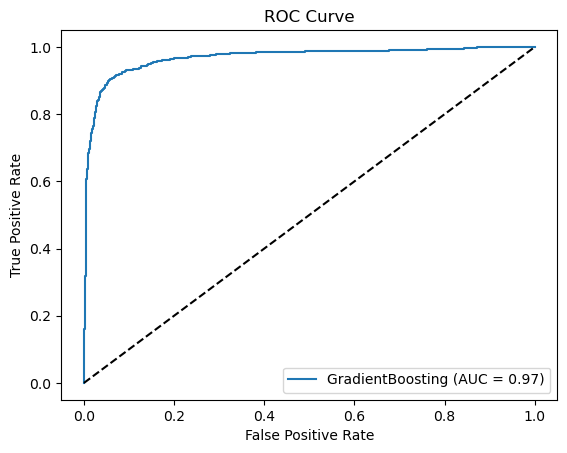

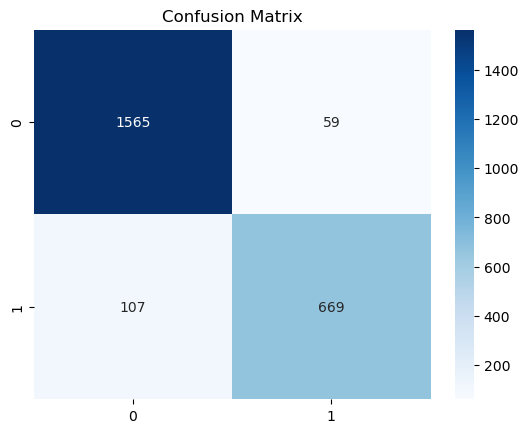

In [12]:
# Графики для лучшей модели
from sklearn.metrics import roc_curve, confusion_matrix
import seaborn as sns

# ROC-кривая
fpr, tpr, _ = roc_curve(y_test, [dummy, pipe_lr, best_dt, best_rf, best_gb, stacking][best_idx].predict_proba(X_test)[:, 1])
plt.figure()
plt.plot(fpr, tpr, label=f'{best_model_name} (AUC = {roc_aucs[best_idx]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.savefig('artifacts/figures/roc_curve.png')
plt.show()

# Confusion Matrix
cm = confusion_matrix(y_test, [dummy, pipe_lr, best_dt, best_rf, best_gb, stacking][best_idx].predict(X_test))
plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.savefig('artifacts/figures/confusion_matrix.png')
plt.show()

In [13]:
# Сохранение артефактов
os.makedirs('artifacts', exist_ok=True)
os.makedirs('artifacts/figures', exist_ok=True)

# metrics_test.json
metrics = {
    'Dummy': {'accuracy': acc_dummy, 'f1': f1_dummy, 'roc_auc': roc_auc_dummy},
    'LogisticRegression': {'accuracy': acc_lr, 'f1': f1_lr, 'roc_auc': roc_auc_lr},
    'DecisionTree': {'accuracy': acc_dt, 'f1': f1_dt, 'roc_auc': roc_auc_dt},
    'RandomForest': {'accuracy': acc_rf, 'f1': f1_rf, 'roc_auc': roc_auc_rf},
    'GradientBoosting': {'accuracy': acc_gb, 'f1': f1_gb, 'roc_auc': roc_auc_gb},
    'Stacking': {'accuracy': acc_st, 'f1': f1_st, 'roc_auc': roc_auc_st}
}
with open('artifacts/metrics_test.json', 'w') as f:
    json.dump(metrics, f, indent=4)

# search_summaries.json
search_summaries = {
    'DecisionTree': {'best_params': grid_dt.best_params_, 'best_score': grid_dt.best_score_},
    'RandomForest': {'best_params': grid_rf.best_params_, 'best_score': grid_rf.best_score_},
    'GradientBoosting': {'best_params': grid_gb.best_params_, 'best_score': grid_gb.best_score_}
}
with open('artifacts/search_summaries.json', 'w') as f:
    json.dump(search_summaries, f, indent=4)

# best_model.joblib
joblib.dump(best_model, 'artifacts/best_model.joblib')

# best_model_meta.json
meta = {
    'best_model': best_model_name,
    'params': str(best_model.get_params()) if hasattr(best_model, 'get_params') else 'N/A',
    'accuracy': accuracies[best_idx],
    'f1': f1s[best_idx],
    'roc_auc': roc_aucs[best_idx]
}
with open('artifacts/best_model_meta.json', 'w') as f:
    json.dump(meta, f, indent=4)

print("Артефакты сохранены.")

Артефакты сохранены.
